In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import mlflow
mlflow.set_tracking_uri("file:///C:/mlruns_1")
mlflow.set_experiment("Crime PCA Analysis")


c:\Users\Rukshana Afrin A\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///C:/mlruns_1/937938924565776964', creation_time=1776098702320, experiment_id='937938924565776964', last_update_time=1776098702320, lifecycle_stage='active', name='Crime PCA Analysis', tags={}, workspace='default'>

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv("Crimes_-_2001_to_Present.csv")

In [4]:
df.shape

(8521648, 22)

In [5]:
df.head(5)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14144404,JK190480,03/22/2026 12:00:00 AM,026XX W 47TH ST,0710,THEFT,THEFT FROM MOTOR VEHICLE,STREET,False,False,922,9.0,15.0,58.0,06,1159371.0,1873402.0,2026,03/29/2026 03:52:45 PM,41.808335,-87.690988,"(41.808334706, -87.690988083)"
1,14148548,JK195044,03/22/2026 12:00:00 AM,005XX S CLINTON ST,0810,THEFT,OVER $500,STREET,False,False,124,1.0,34.0,28.0,06,1172810.0,1897826.0,2026,03/29/2026 03:52:45 PM,41.875070,-87.640975,"(41.875070002, -87.640974928)"
2,14147626,JK191544,03/22/2026 12:00:00 AM,008XX W 50TH PL,0460,BATTERY,SIMPLE,RESIDENCE,False,False,933,9.0,20.0,61.0,08B,1171525.0,1871362.0,2026,03/29/2026 03:52:45 PM,41.802479,-87.646470,"(41.802478809, -87.646469896)"
3,14149242,JK196261,03/22/2026 12:00:00 AM,002XX W 22ND PL,0265,CRIMINAL SEXUAL ASSAULT,AGGRAVATED - OTHER,HOTEL / MOTEL,False,True,914,9.0,11.0,34.0,02,1175079.0,1889496.0,2026,03/29/2026 03:52:45 PM,41.852161,-87.632894,"(41.852161388, -87.632893697)"
4,14144577,JK190695,03/22/2026 12:00:00 AM,033XX N NARRAGANSETT AVE,5132,OTHER OFFENSE,VIOLENT OFFENDER - FAIL TO REGISTER NEW ADDRESS,RESIDENCE,False,False,1632,16.0,36.0,17.0,26,1133108.0,1921729.0,2026,03/29/2026 03:52:45 PM,41.941449,-87.786186,"(41.941449171, -87.786186447)"


In [6]:
df_sample = df.sample(n=500000, random_state=42)

print(df_sample.shape)
print(df_sample['Primary Type'].value_counts())

(500000, 22)
Primary Type
THEFT                                106696
BATTERY                               90976
CRIMINAL DAMAGE                       56682
NARCOTICS                             45021
ASSAULT                               33652
OTHER OFFENSE                         31334
BURGLARY                              26423
MOTOR VEHICLE THEFT                   25632
DECEPTIVE PRACTICE                    23117
ROBBERY                               18441
CRIMINAL TRESPASS                     13515
WEAPONS VIOLATION                      7462
PROSTITUTION                           3994
OFFENSE INVOLVING CHILDREN             3500
PUBLIC PEACE VIOLATION                 3305
SEX OFFENSE                            2044
CRIM SEXUAL ASSAULT                    1545
INTERFERENCE WITH PUBLIC OFFICER       1208
LIQUOR LAW VIOLATION                    937
HOMICIDE                                847
GAMBLING                                821
ARSON                                   803
CRIMIN

In [7]:
df_main=df_sample.copy()

In [8]:
df_main.shape

(500000, 22)

In [9]:
df_main.head(5)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
2928898,9700365,HX350285,07/18/2014 02:48:00 PM,084XX S SANGAMON ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,RESIDENTIAL YARD (FRONT/BACK),True,False,613,6.0,21.0,71.0,18,1171451.0,1848852.0,2014,02/10/2018 03:50:01 PM,41.740710,-87.647400,"(41.740710277, -87.647399696)"
4472158,7259302,HR668519,12/01/2009 08:27:39 AM,058XX S SACRAMENTO AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE-GARAGE,False,False,824,8.0,14.0,63.0,14,1157378.0,1865790.0,2009,02/10/2018 03:50:01 PM,41.787487,-87.698504,"(41.787486983, -87.698504174)"
337419,13625398,JH461975,10/09/2024 03:20:00 PM,052XX W MADISON ST,0560,ASSAULT,SIMPLE,DRUG STORE,False,False,1522,15.0,37.0,25.0,08A,1141512.0,1899523.0,2024,05/17/2025 03:40:52 PM,41.880362,-87.755847,"(41.880362084, -87.755847438)"
533147,13336874,JH113705,01/12/2024 03:48:00 PM,031XX W MADISON ST,0496,BATTERY,AGGRAVATED DOMESTIC BATTERY - KNIFE / CUTTING ...,APARTMENT,False,True,1124,11.0,28.0,27.0,04B,1155522.0,1899851.0,2024,12/21/2024 03:40:46 PM,41.880992,-87.704395,"(41.880991939, -87.704394994)"
5202710,6106876,HP200474,02/29/2008 10:15:00 AM,023XX W 64TH ST,0545,ASSAULT,PRO EMP HANDS NO/MIN INJURY,"SCHOOL, PUBLIC, BUILDING",True,False,825,8.0,15.0,66.0,08A,1162090.0,1862158.0,2008,02/28/2018 03:56:25 PM,41.777424,-87.681328,"(41.777423514, -87.681328162)"


In [10]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 2928898 to 1827039
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    500000 non-null  int64  
 1   Case Number           500000 non-null  object 
 2   Date                  500000 non-null  object 
 3   Block                 500000 non-null  object 
 4   IUCR                  500000 non-null  object 
 5   Primary Type          500000 non-null  object 
 6   Description           500000 non-null  object 
 7   Location Description  499082 non-null  object 
 8   Arrest                500000 non-null  bool   
 9   Domestic              500000 non-null  bool   
 10  Beat                  500000 non-null  int64  
 11  District              499999 non-null  float64
 12  Ward                  463870 non-null  float64
 13  Community Area        463917 non-null  float64
 14  FBI Code              500000 non-null  object 
 15

In [11]:
df_main.describe()

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,5.000000e+05,500000.000000,499999.000000,463870.000000,463917.000000,4.943180e+05,4.943180e+05,500000.000000,494318.000000,494318.000000
mean,7.589727e+06,1184.355174,11.305423,22.808690,37.366699,1.164678e+06,1.885950e+06,2011.172732,41.842641,-87.671205
std,3.828680e+06,704.872059,6.976445,13.867218,21.555799,1.678956e+04,3.224933e+04,7.207588,0.088721,0.060893
min,6.850000e+02,111.000000,1.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,2001.000000,36.619446,-91.686566
25%,4.092401e+06,621.000000,6.000000,10.000000,23.000000,1.153109e+06,1.859257e+06,2005.000000,41.769087,-87.713155
50%,7.587918e+06,1034.000000,10.000000,23.000000,32.000000,1.166196e+06,1.891024e+06,2010.000000,41.856644,-87.665570
75%,1.103075e+07,1731.000000,17.000000,34.000000,56.000000,1.176400e+06,1.909408e+06,2017.000000,41.907086,-87.628070
max,1.414924e+07,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951532e+06,2026.000000,42.022643,-87.524529


In [12]:
df_main.isnull().sum()

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description      918
Arrest                      0
Domestic                    0
Beat                        0
District                    1
Ward                    36130
Community Area          36083
FBI Code                    0
X Coordinate             5682
Y Coordinate             5682
Year                        0
Updated On                  0
Latitude                 5682
Longitude                5682
Location                 5682
dtype: int64

In [13]:
df_main["Date"]=pd.to_datetime(df_main["Date"],errors="coerce")

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\4122177989.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main["Date"]=pd.to_datetime(df_main["Date"],errors="coerce")


In [14]:
df_main["Date"].dtype

dtype('<M8[ns]')

In [15]:
df_main["Date"].isnull().sum()

np.int64(0)

In [16]:
df_main["Primary Type"].unique()

array(['NARCOTICS', 'CRIMINAL DAMAGE', 'ASSAULT', 'BATTERY', 'THEFT',
       'BURGLARY', 'CRIMINAL TRESPASS', 'ROBBERY', 'OTHER OFFENSE',
       'DECEPTIVE PRACTICE', 'PROSTITUTION', 'SEX OFFENSE',
       'INTERFERENCE WITH PUBLIC OFFICER', 'MOTOR VEHICLE THEFT',
       'LIQUOR LAW VIOLATION', 'WEAPONS VIOLATION', 'GAMBLING',
       'INTIMIDATION', 'KIDNAPPING', 'PUBLIC PEACE VIOLATION', 'HOMICIDE',
       'OFFENSE INVOLVING CHILDREN', 'OTHER NARCOTIC VIOLATION',
       'CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT', 'STALKING',
       'ARSON', 'CONCEALED CARRY LICENSE VIOLATION', 'OBSCENITY',
       'RITUALISM', 'PUBLIC INDECENCY', 'HUMAN TRAFFICKING'], dtype=object)

In [17]:
df_main[df_main["Location Description"].isnull()]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
3384034,11825036,JC429150,2013-01-01 16:10:00,064XX S DR MARTIN LUTHER KING JR DR,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,312,3.0,20.0,69.0,11,NaN,NaN,2013,09/12/2019 03:41:38 PM,NaN,NaN,NaN
1413359,12019387,JD196635,2020-03-28 04:30:00,005XX S PLYMOUTH CT,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,123,1.0,4.0,32.0,11,1176154.0,1897914.0,2020,04/04/2020 03:41:46 PM,41.875237,-87.628695,"(41.875236804, -87.628694598)"
1773353,12913458,JF498770,2018-10-29 10:30:00,024XX S ALBANY AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,1033,10.0,12.0,30.0,11,NaN,NaN,2018,12/06/2022 03:42:01 PM,NaN,NaN,NaN
764163,13091808,JG281769,2023-03-01 11:25:00,043XX S TROY ST,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,NaN,False,False,922,9.0,12.0,58.0,11,1156084.0,1875552.0,2023,08/19/2023 03:40:26 PM,41.814301,-87.702986,"(41.814301373, -87.702986274)"
2546845,10549607,HZ295697,2015-12-16 14:05:00,012XX W Fletcher St,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,1933,19.0,32.0,6.0,11,NaN,NaN,2015,06/07/2016 03:57:55 PM,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918670,13207477,JG420243,2022-07-25 00:00:00,054XX S HYDE PARK BLVD,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,234,2.0,5.0,41.0,11,NaN,NaN,2022,09/12/2023 03:44:38 PM,NaN,NaN,NaN
2696819,11862982,JC474657,2015-06-01 09:25:00,067XX S BENNETT AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,332,3.0,5.0,43.0,11,NaN,NaN,2015,10/17/2019 03:44:03 PM,NaN,NaN,NaN
1042734,12786853,JF347403,2022-01-03 18:45:00,049XX N Wolcott Ave,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,2032,20.0,47.0,4.0,11,1162927.0,1932768.0,2022,01/03/2023 03:40:27 PM,41.971166,-87.676278,"(41.971166137, -87.676278141)"
1937301,11278673,JB215319,2018-04-02 11:30:00,018XX W JACKSON BLVD,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,1225,12.0,2.0,28.0,11,1164248.0,1898656.0,2018,05/04/2018 03:51:04 PM,41.877533,-87.672388,"(41.877532811, -87.672387519)"


In [18]:
df_main["Location Description"].isnull().mean()*100

np.float64(0.18359999999999999)

In [19]:
df_main.dropna(subset=["Location Description"],inplace=True)

In [20]:
df_main["Location Description"].isnull().sum()

np.int64(0)

In [21]:
df_main["Arrest"].dtypes

dtype('bool')

In [22]:
df_main["Arrest"].isnull().sum()

np.int64(0)

In [23]:
df_main["Domestic"].dtype

dtype('bool')

In [24]:
df_main["Domestic"].isnull().sum()

np.int64(0)

In [25]:
df_main["Beat"].isnull().sum()

np.int64(0)

In [26]:
df_main["District"].isnull().sum()

np.int64(1)

In [27]:
df_main.dropna(subset=["District"],inplace=True)

In [28]:
df_main["District"].dtype

dtype('float64')

In [29]:
df_main["District"].isnull().sum()

np.int64(0)

In [30]:
df_main["Ward"].dtype

dtype('float64')

In [31]:
df_main["Ward"].isnull().sum()

np.int64(36129)

In [32]:
df_main["Ward"].isnull().mean()*100

np.float64(7.23910547586464)

In [33]:
df_main[df_main["Community Area"].isnull()]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
7966158,2006800,HH210781,2002-02-26 17:00:00,132XX S VERNON AV,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,533,5.0,NaN,NaN,14,1181505.0,1817649.0,2002,02/28/2018 03:56:25 PM,41.654859,-87.611521,"(41.654859227, -87.611521129)"
8386191,1485065,G220489,2001-04-18 13:52:43,005XX N SPAULDING AV,0820,THEFT,$500 AND UNDER,RESIDENCE,False,False,1121,11.0,NaN,NaN,06,1154318.0,1903527.0,2001,08/17/2015 03:03:40 PM,41.891103,-87.708718,"(41.891103377, -87.708717772)"
8470671,1376464,G086965,2001-02-11 15:30:00,002XX W ADAMS ST,0820,THEFT,$500 AND UNDER,PARKING LOT/GARAGE(NON.RESID.),False,False,112,1.0,NaN,NaN,06,1174669.0,1899372.0,2001,08/17/2015 03:03:40 PM,41.879271,-87.634103,"(41.879270971, -87.634103259)"
7897874,2091169,HH320578,2002-04-20 20:55:00,062XX S VERNON AV,051A,ASSAULT,AGGRAVATED: HANDGUN,RESIDENCE PORCH/HALLWAY,False,False,313,3.0,NaN,NaN,04A,1180322.0,1863789.0,2002,02/28/2018 03:56:25 PM,41.781500,-87.614440,"(41.781500367, -87.614440016)"
8355768,1523905,G269079,2001-05-10 11:50:00,060XX S WESTERN AV,0820,THEFT,$500 AND UNDER,STREET,False,False,825,8.0,NaN,NaN,06,1161438.0,1864785.0,2001,08/17/2015 03:03:40 PM,41.784646,-87.683646,"(41.784645902, -87.683645642)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7937618,2048477,HH256947,2002-03-21 17:10:00,016XX S SPRINGFIELD AV,2027,NARCOTICS,POSS: CRACK,STREET,True,False,1014,10.0,NaN,NaN,18,1150668.0,1891495.0,2002,02/28/2018 03:56:25 PM,41.858158,-87.722437,"(41.858158349, -87.722437028)"
8373797,1503660,G247851,2001-04-27 15:00:00,047XX N SHERIDAN RD,0620,BURGLARY,UNLAWFUL ENTRY,RESIDENCE,False,False,2312,19.0,NaN,NaN,05,1168730.0,1931933.0,2001,08/17/2015 03:03:40 PM,41.968751,-87.654964,"(41.968750763, -87.6549643)"
8320549,1565197,G326158,2001-06-05 20:14:00,127XX S ESCANABA AV,0460,BATTERY,SIMPLE,STREET,False,False,433,4.0,NaN,NaN,08B,1197455.0,1820907.0,2001,08/17/2015 03:03:40 PM,41.663418,-87.553053,"(41.663418238, -87.553052636)"
8256347,1645745,G427532,2001-07-21 05:22:08,119XX S HALSTED ST,0320,ROBBERY,STRONGARM - NO WEAPON,STREET,False,False,524,5.0,NaN,NaN,03,1173193.0,1825357.0,2001,08/17/2015 03:03:40 PM,41.676198,-87.641709,"(41.67619825, -87.641708587)"


In [34]:
df_main["Community Area"].isnull().sum()

np.int64(36082)

In [35]:
df_main["Community Area"].isnull().mean()*100

np.float64(7.229688166850671)

In [36]:
df_main["FBI Code"].dtype

dtype('O')

In [37]:
df_main["FBI Code"].isnull().sum()

np.int64(0)

In [38]:
df_main['X Coordinate'].isnull().sum()

np.int64(5374)

In [39]:
df_main['X Coordinate'].isnull().mean()*100

np.float64(1.0767791200226016)

In [40]:
df_main.dropna(subset="X Coordinate",inplace=True)

In [41]:
df_main['Y Coordinate'].isnull().sum()

np.int64(0)

In [42]:
df_main['Y Coordinate'].isnull().sum()

np.int64(0)

In [43]:
df_main.isnull().sum()

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description        0
Arrest                      0
Domestic                    0
Beat                        0
District                    0
Ward                    35551
Community Area          35507
FBI Code                    0
X Coordinate                0
Y Coordinate                0
Year                        0
Updated On                  0
Latitude                    0
Longitude                   0
Location                    0
dtype: int64

In [44]:
df_main.dtypes

ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                           object
IUCR                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                            bool
Domestic                          bool
Beat                             int64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                        object
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Updated On                      object
Latitude                       float64
Longitude                      float64
Location                        object
dtype: object

In [45]:
df_main.head(3)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
2928898,9700365,HX350285,2014-07-18 14:48:00,084XX S SANGAMON ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,RESIDENTIAL YARD (FRONT/BACK),True,False,613,6.0,21.0,71.0,18,1171451.0,1848852.0,2014,02/10/2018 03:50:01 PM,41.740710,-87.647400,"(41.740710277, -87.647399696)"
4472158,7259302,HR668519,2009-12-01 08:27:39,058XX S SACRAMENTO AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE-GARAGE,False,False,824,8.0,14.0,63.0,14,1157378.0,1865790.0,2009,02/10/2018 03:50:01 PM,41.787487,-87.698504,"(41.787486983, -87.698504174)"
337419,13625398,JH461975,2024-10-09 15:20:00,052XX W MADISON ST,0560,ASSAULT,SIMPLE,DRUG STORE,False,False,1522,15.0,37.0,25.0,08A,1141512.0,1899523.0,2024,05/17/2025 03:40:52 PM,41.880362,-87.755847,"(41.880362084, -87.755847438)"


In [46]:
df_main["Updated On	"]=pd.to_datetime(df_main["Updated On"])

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\936536774.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main["Updated On	"]=pd.to_datetime(df_main["Updated On"])


In [50]:
# Drop useless columns (UPDATED for lowercase)
df_main.drop(["id", "case number", "updated on", "block"], axis=1, inplace=True, errors='ignore')


# Fix categorical geography
geo_cols = ["beat", "district", "ward", "community area"]

for col in geo_cols:
    if col in df_main.columns:
        df_main[col] = df_main[col].astype("category")


# Fill missing categorical values
if "ward" in df_main.columns:
    df_main["ward"].fillna(df_main["ward"].mode()[0], inplace=True)

if "community area" in df_main.columns:
    df_main["community area"].fillna(df_main["community area"].mode()[0], inplace=True)


# Drop duplicate spatial columns (since lat/long already exist)
df_main.drop(["x coordinate", "y coordinate", "location"], axis=1, inplace=True, errors='ignore')


# Ensure datetime format
df_main["date"] = pd.to_datetime(df_main["date"], errors="coerce")

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\3406193566.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_main["ward"].fillna(df_main["ward"].mode()[0], inplace=True)
C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\3406193566.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

In [51]:
df_main = df_main.loc[:, ~df_main.columns.duplicated()]

In [52]:
df_main["fbi code"] = df_main["fbi code"].astype("category")

In [53]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493707 entries, 2928898 to 1827039
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   date                  493707 non-null  datetime64[ns]
 1   iucr                  493707 non-null  object        
 2   primary type          493707 non-null  object        
 3   description           493707 non-null  object        
 4   location description  493707 non-null  object        
 5   arrest                493707 non-null  bool          
 6   domestic              493707 non-null  bool          
 7   beat                  493707 non-null  category      
 8   district              493707 non-null  category      
 9   ward                  493707 non-null  category      
 10  community area        493707 non-null  category      
 11  fbi code              493707 non-null  category      
 12  year                  493707 non-null  int64         
 1

In [54]:
df_main.isnull().sum()

date                    0
iucr                    0
primary type            0
description             0
location description    0
arrest                  0
domestic                0
beat                    0
district                0
ward                    0
community area          0
fbi code                0
year                    0
latitude                0
longitude               0
dtype: int64

In [55]:
df_main.columns = df_main.columns.str.strip().str.lower()

In [56]:
df_main.drop(["updated on"], axis=1, inplace=True, errors='ignore')

In [57]:

# Remove accidental feature columns (if created earlier)
#df_main.drop(["hour", "day", "month"], axis=1, inplace=True, errors='ignore')

# Convert geography to category
geo_cols = ["beat", "district", "ward", "community area"]
for col in geo_cols:
    if col in df_main.columns:
        df_main[col] = df_main[col].astype("category")

# Fill missing properly (no warnings)
df_main["ward"] = df_main["ward"].fillna(df_main["ward"].mode()[0])
df_main["community area"] = df_main["community area"].fillna(df_main["community area"].mode()[0])

# Drop redundant spatial columns
df_main.drop(["x coordinate", "y coordinate", "location"], axis=1, inplace=True, errors='ignore')



In [58]:
df_main.isnull().sum()

date                    0
iucr                    0
primary type            0
description             0
location description    0
arrest                  0
domestic                0
beat                    0
district                0
ward                    0
community area          0
fbi code                0
year                    0
latitude                0
longitude               0
dtype: int64

In [59]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493707 entries, 2928898 to 1827039
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   date                  493707 non-null  datetime64[ns]
 1   iucr                  493707 non-null  object        
 2   primary type          493707 non-null  object        
 3   description           493707 non-null  object        
 4   location description  493707 non-null  object        
 5   arrest                493707 non-null  bool          
 6   domestic              493707 non-null  bool          
 7   beat                  493707 non-null  category      
 8   district              493707 non-null  category      
 9   ward                  493707 non-null  category      
 10  community area        493707 non-null  category      
 11  fbi code              493707 non-null  category      
 12  year                  493707 non-null  int64         
 1

In [60]:
df_main['primary type'].value_counts()

primary type
THEFT                                105340
BATTERY                               90542
CRIMINAL DAMAGE                       56380
NARCOTICS                             44281
ASSAULT                               33511
OTHER OFFENSE                         31059
BURGLARY                              26314
MOTOR VEHICLE THEFT                   25408
DECEPTIVE PRACTICE                    21258
ROBBERY                               18343
CRIMINAL TRESPASS                     13452
WEAPONS VIOLATION                      7429
PROSTITUTION                           3964
PUBLIC PEACE VIOLATION                 3281
OFFENSE INVOLVING CHILDREN             3219
SEX OFFENSE                            1915
CRIM SEXUAL ASSAULT                    1451
INTERFERENCE WITH PUBLIC OFFICER       1204
LIQUOR LAW VIOLATION                    928
HOMICIDE                                847
GAMBLING                                817
ARSON                                   798
CRIMINAL SEXUAL ASS

<Axes: xlabel='primary type'>

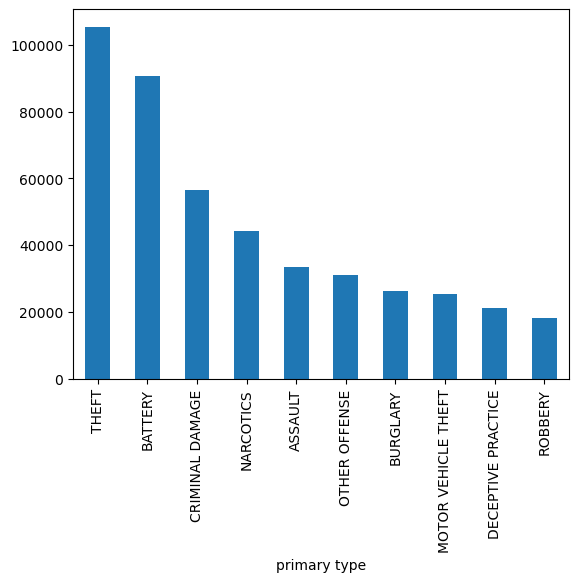

In [61]:
df_main['primary type'].value_counts().head(10).plot(kind='bar')

In [62]:
df_main['date'] = pd.to_datetime(df_main['date'])

In [63]:
df_main['hour'] = df_main['date'].dt.hour
df_main['day'] = df_main['date'].dt.day_name()
df_main['month'] = df_main['date'].dt.month

In [64]:
df_main.columns = df_main.columns.str.lower()

<Axes: xlabel='hour'>

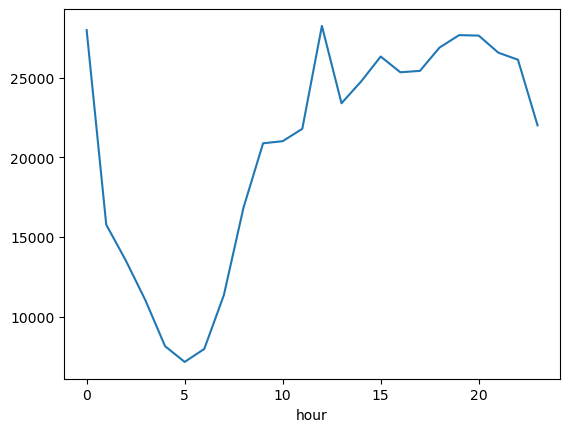

In [65]:
df_main['hour'].value_counts().sort_index().plot()

<Axes: xlabel='day'>

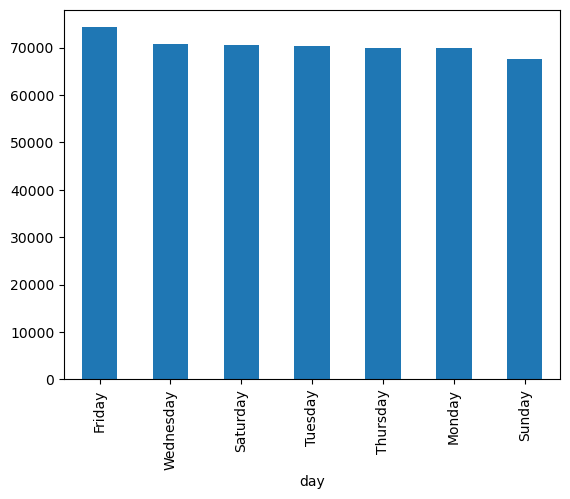

In [66]:
df_main['day'].value_counts().plot(kind='bar')

In [67]:
df_main = df_main[
    (df_main['latitude'].between(41.6, 42.1)) &
    (df_main['longitude'].between(-88, -87.5))
]

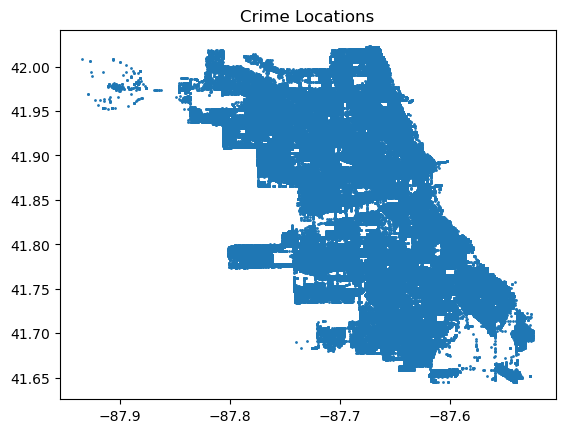

In [68]:
plt.scatter(df_main['longitude'], df_main['latitude'], s=1)
plt.title("Crime Locations")
plt.show()

In [69]:
df_main['arrest'].value_counts()

arrest
False    369121
True     124579
Name: count, dtype: int64

In [70]:
df_main['domestic'].value_counts()

domestic
False    408119
True      85581
Name: count, dtype: int64

In [71]:
pd.crosstab(df_main["primary type"], df_main['arrest'])

arrest,False,True
primary type,,
ARSON,706,92
ASSAULT,26752,6759
BATTERY,70858,19683
BURGLARY,24768,1546
CONCEALED CARRY LICENSE VIOLATION,4,102
CRIM SEXUAL ASSAULT,1219,232
CRIMINAL DAMAGE,52705,3674
CRIMINAL SEXUAL ASSAULT,629,50
CRIMINAL TRESPASS,4410,9042


In [72]:
df_main.drop(columns=['ward', 'community area'], inplace=True)
print(df_main.shape)

(493700, 16)


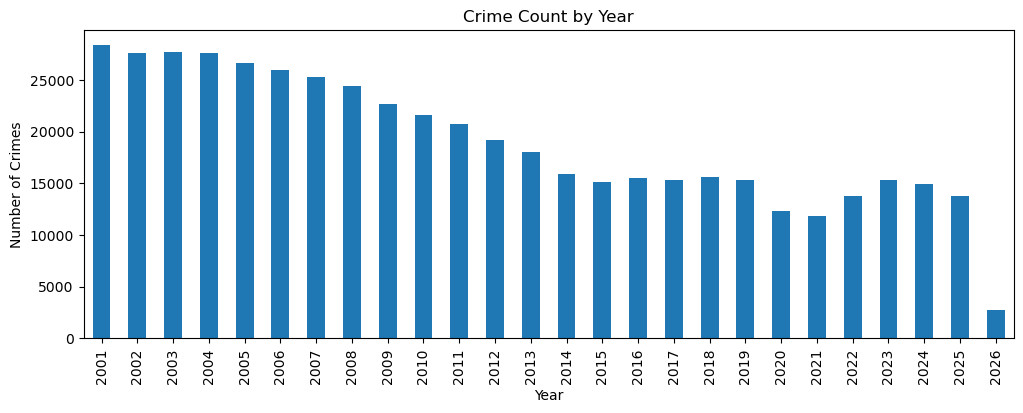

In [73]:
df_main['year'].value_counts().sort_index().plot(kind='bar', 
                                                  figsize=(12,4))
plt.title('Crime Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.show()

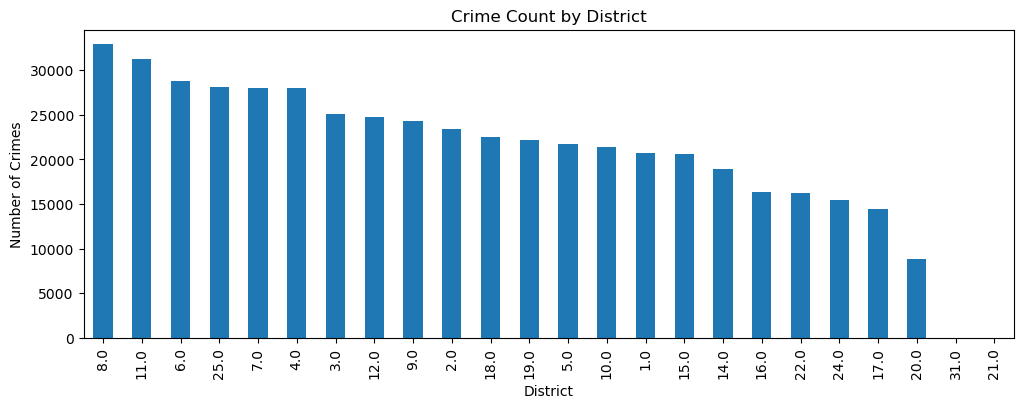

In [74]:
df_main['district'].value_counts().plot(kind='bar', figsize=(12,4))
plt.title('Crime Count by District')
plt.xlabel('District')
plt.ylabel('Number of Crimes')
plt.show()

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\1030167590.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recent.groupby(['year', 'district']).size().unstack().plot(


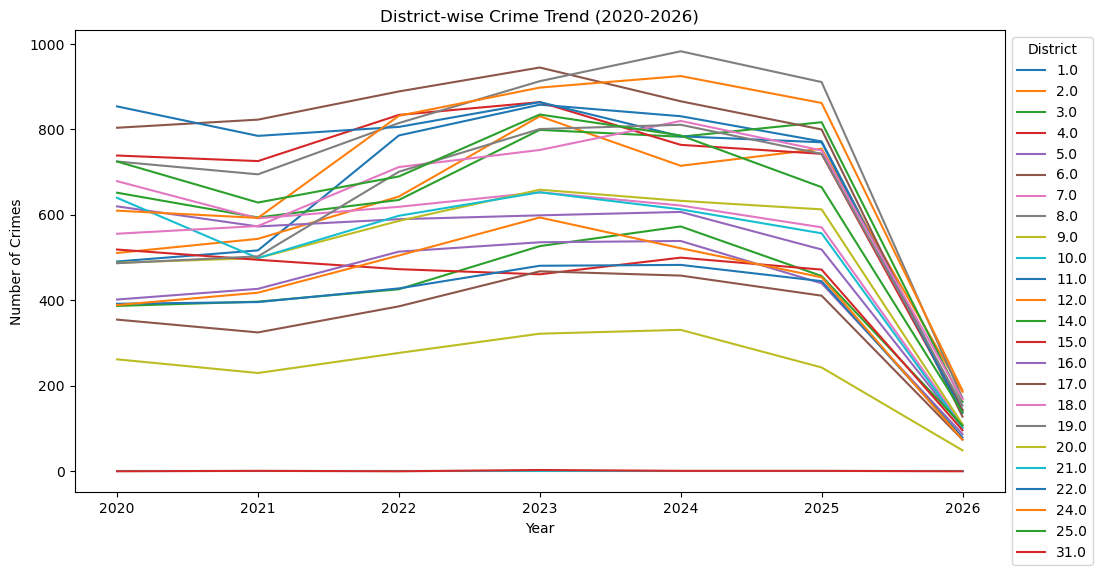

In [75]:
# Year wise crime count by district (recent years only)
recent = df_main[df_main['year'] >= 2020]
recent.groupby(['year', 'district']).size().unstack().plot(
    figsize=(12,6))
plt.title('District-wise Crime Trend (2020-2026)')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.legend(title='District', bbox_to_anchor=(1,1))
plt.show()

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\2113293542.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['year','district']).size().unstack()\


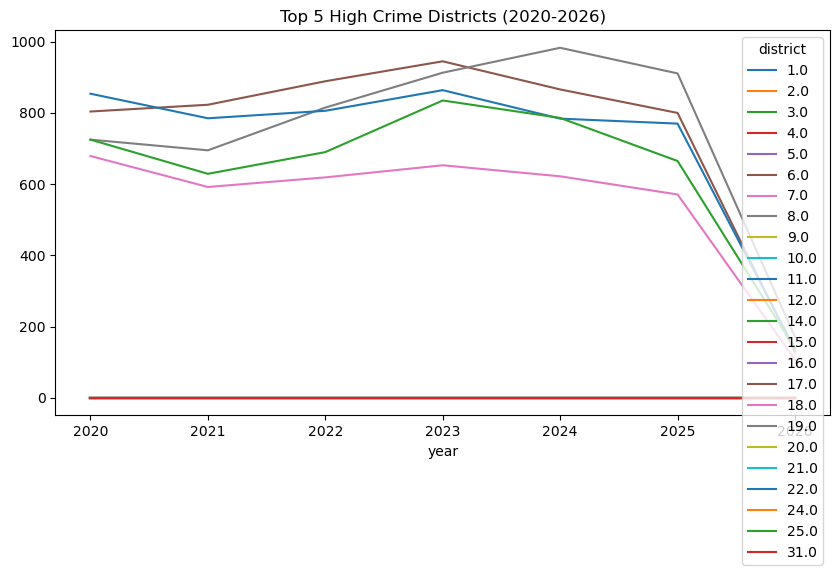

In [76]:
top5_districts = df_main['district'].value_counts().head(5).index

recent = df_main[df_main['year'] >= 2020]
recent[recent['district'].isin(top5_districts)]\
    .groupby(['year','district']).size().unstack()\
    .plot(figsize=(10,5))
plt.title('Top 5 High Crime Districts (2020-2026)')
plt.show()

In [77]:
df_main.head(3)

,date,iucr,primary type,description,location description,arrest,domestic,beat,district,fbi code,year,latitude,longitude,hour,day,month
2928898,2014-07-18 14:48:00,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,RESIDENTIAL YARD (FRONT/BACK),True,False,613,6.0,18,2014,41.740710,-87.647400,14,Friday,7
4472158,2009-12-01 08:27:39,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE-GARAGE,False,False,824,8.0,14,2009,41.787487,-87.698504,8,Tuesday,12
337419,2024-10-09 15:20:00,0560,ASSAULT,SIMPLE,DRUG STORE,False,False,1522,15.0,08A,2024,41.880362,-87.755847,15,Wednesday,10


In [78]:
df_main.shape

(493700, 16)

In [79]:
top_types = df_main['primary type'].value_counts().nlargest(8).index

df_main['primary type'] = df_main['primary type'].apply(
    lambda x: x if x in top_types else 'OTHER'
)

In [80]:
df_main = df_main[df_main['year'] < 2026]

In [81]:
df_main["primary type"].unique()

array(['NARCOTICS', 'CRIMINAL DAMAGE', 'ASSAULT', 'BATTERY', 'THEFT',
       'BURGLARY', 'OTHER', 'OTHER OFFENSE', 'MOTOR VEHICLE THEFT'],
      dtype=object)

In [82]:
# ============================================
# ✅ STEP 1: PRIMARY TYPE REDUCTION
# ============================================
top_types = df_main['primary type'].value_counts().nlargest(8).index

df_main['primary type'] = df_main['primary type'].apply(
    lambda x: x if x in top_types else 'OTHER'
)


# ============================================
# ✅ STEP 2: CRIME SEVERITY (ALIGNED)
# ============================================
severity_map = {
    'ASSAULT': 7,
    'BATTERY': 6,
    'BURGLARY': 5,
    'MOTOR VEHICLE THEFT': 4,
    'THEFT': 3,
    'CRIMINAL DAMAGE': 3,
    'OTHER OFFENSE': 3,
    'NARCOTICS': 2,
    'OTHER': 2
}

df_main['crime_severity'] = df_main['primary type'].map(severity_map).fillna(2)


# ============================================
# ✅ STEP 3: DISTRICT FEATURES
# ============================================
df_main['district_crime_count'] = df_main.groupby('district')['primary type'].transform('count')

df_main['district_avg_severity'] = df_main.groupby('district')['crime_severity'].transform('mean')


# ============================================
# ✅ STEP 4: GEO CLEANING (KEEP THIS)
# ============================================
df_main = df_main[
    (df_main['latitude'].between(41.6, 42.1)) &
    (df_main['longitude'].between(-88, -87.5))
]

df_main = df_main.dropna(subset=['latitude', 'longitude'])


# ============================================
# ✅ STEP 5: SMART GEO BINNING (IMPORTANT)
# ============================================
df_main['lat_bin'] = pd.qcut(df_main['latitude'], q=5, labels=False, duplicates='drop')
df_main['lon_bin'] = pd.qcut(df_main['longitude'], q=5, labels=False, duplicates='drop')


# ============================================
# ✅ STEP 6: GEO REGION FEATURE
# ============================================
df_main['geo_region'] = df_main['lat_bin'].astype(str) + "_" + df_main['lon_bin'].astype(str)


# ============================================
# ✅ STEP 7: WEEKEND FEATURE
# ============================================
df_main['weekend_flag'] = df_main['day'].isin(['Saturday', 'Sunday']).astype(int)


# ============================================
# ✅ STEP 8: LOCATION CATEGORY (CLEANED)
# ============================================
def categorize_location(loc):
    loc = str(loc).upper()

    # 🏠 Residential
    if any(x in loc for x in ['RESIDENCE', 'APARTMENT', 'HOUSE', 'PORCH', 'GARAGE', 'YARD', 'DRIVEWAY', 'HALLWAY']):
        return 'residential'

    # 🚶 Street / Public
    elif any(x in loc for x in ['STREET', 'SIDEWALK', 'ALLEY', 'HIGHWAY', 'EXPRESSWAY']):
        return 'street'

    # 🏪 Commercial
    elif any(x in loc for x in ['STORE', 'RESTAURANT', 'BANK', 'HOTEL', 'TAVERN', 'GAS STATION', 'BAR', 'ATM']):
        return 'commercial'

    # 🏫 Institutional (UPDATED)
    elif any(x in loc for x in ['SCHOOL', 'COLLEGE', 'UNIVERSITY', 'HOSPITAL', 'CHURCH', 'LIBRARY', 'MEDICAL']):
        return 'institutional'

    # 🌳 Outdoor
    elif any(x in loc for x in ['PARK', 'FOREST', 'LAKE', 'RIVER', 'VACANT', 'PLAYGROUND']):
        return 'outdoor'

    # 🚗 Transport
    elif any(x in loc for x in ['VEHICLE', 'CTA', 'BUS', 'TRAIN', 'AIRPORT', 'PLATFORM', 'TAXICAB']):
        return 'transport'

    # 🏭 Industrial (UPDATED)
    elif any(x in loc for x in ['FACTORY', 'WAREHOUSE', 'GOVERNMENT', 'BUILDING', 'CONSTRUCTION', 'SITE']):
        return 'industrial'

    # 🎯 Recreational (NEW)
    elif any(x in loc for x in ['STADIUM', 'ARENA', 'CLUB']):
        return 'recreational'

    else:
        return 'other'


df_main['location_category'] = df_main['location description'].apply(categorize_location)


# ============================================
# ✅ STEP 9: (OPTIONAL BUT USEFUL) REGION DENSITY
# ============================================
df_main['region_crime_count'] = df_main.groupby('geo_region')['primary type'].transform('count')


# ============================================
# ✅ STEP 10: FINAL CHECK
# ============================================
print("Final Shape:", df_main.shape)
print("Columns Added Successfully ✅")

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\3071761449.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_main['district_crime_count'] = df_main.groupby('district')['primary type'].transform('count')
C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_15836\3071761449.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_main['district_avg_severity'] = df_main.groupby('district')['crime_severity'].transform('mean')


Final Shape: (490993, 25)
Columns Added Successfully ✅


In [83]:
df_main['location_category'].value_counts()

location_category
street           184589
residential      182725
commercial        50620
transport         22091
other             20297
institutional     16535
outdoor           10045
industrial         3118
recreational        973
Name: count, dtype: int64

In [84]:
# Check for missing severity values
print("Missing severity values:")
print(df_main[df_main['crime_severity'].isna()]['primary type'].value_counts())

Missing severity values:
Series([], Name: count, dtype: int64)


In [85]:
# Compare unique values vs severity map
print("Unique primary types:")
print(df_main['primary type'].unique())

print("\nMapped categories:")
print(severity_map.keys())

Unique primary types:
['NARCOTICS' 'CRIMINAL DAMAGE' 'ASSAULT' 'BATTERY' 'THEFT' 'BURGLARY'
 'OTHER' 'OTHER OFFENSE']

Mapped categories:
dict_keys(['ASSAULT', 'BATTERY', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'THEFT', 'CRIMINAL DAMAGE', 'OTHER OFFENSE', 'NARCOTICS', 'OTHER'])


In [86]:
# Check if anything fell into 'other'
print("\nSample of 'other' locations:")
print(df_main[df_main['location_category'] == 'other']['location description'].value_counts().head(10))


Sample of 'other' locations:
location description
OTHER                              15626
OTHER (SPECIFY)                     1370
NURSING HOME/RETIREMENT HOME         876
CURRENCY EXCHANGE                    734
NURSING / RETIREMENT HOME            245
OTHER COMMERCIAL TRANSPORTATION      215
CAR WASH                             203
DAY CARE CENTER                      189
AUTO / BOAT / RV DEALERSHIP          102
JAIL / LOCK-UP FACILITY               92
Name: count, dtype: int64


In [87]:
print("Geo region sample:")
print(df_main['geo_region'].value_counts().head())

Geo region sample:
geo_region
0_4    49100
4_0    33975
1_4    33786
3_0    33520
4_2    30960
Name: count, dtype: int64


In [88]:
print(df_main[['district_crime_count', 'district_avg_severity']].describe())

       district_crime_count  district_avg_severity
count         490993.000000          490993.000000
mean           23796.577725               3.622520
std             5325.334857               0.157289
min                1.000000               3.262233
25%            20600.000000               3.537357
50%            24164.000000               3.624629
75%            27936.000000               3.736675
max            32727.000000               6.000000


In [89]:
print("Any nulls left?")
print(df_main.isnull().sum())

Any nulls left?
date                     0
iucr                     0
primary type             0
description              0
location description     0
arrest                   0
domestic                 0
beat                     0
district                 0
fbi code                 0
year                     0
latitude                 0
longitude                0
hour                     0
day                      0
month                    0
crime_severity           0
district_crime_count     0
district_avg_severity    0
lat_bin                  0
lon_bin                  0
geo_region               0
weekend_flag             0
location_category        0
region_crime_count       0
dtype: int64


In [90]:
df_main = df_main.drop(columns=['geo_cluster'], errors='ignore')

In [91]:
df_main.columns.tolist()

['date',
 'iucr',
 'primary type',
 'description',
 'location description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'fbi code',
 'year',
 'latitude',
 'longitude',
 'hour',
 'day',
 'month',
 'crime_severity',
 'district_crime_count',
 'district_avg_severity',
 'lat_bin',
 'lon_bin',
 'geo_region',
 'weekend_flag',
 'location_category',
 'region_crime_count']

In [92]:
drop_cols = [
    'date',
    'iucr',
    'description',
    'location description',
    'fbi code',
    'latitude',
    'longitude'
]

df_model = df_main.drop(columns=drop_cols, errors='ignore')

In [93]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490993 entries, 2928898 to 1827039
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   primary type           490993 non-null  object  
 1   arrest                 490993 non-null  bool    
 2   domestic               490993 non-null  bool    
 3   beat                   490993 non-null  category
 4   district               490993 non-null  category
 5   year                   490993 non-null  int64   
 6   hour                   490993 non-null  int32   
 7   day                    490993 non-null  object  
 8   month                  490993 non-null  int32   
 9   crime_severity         490993 non-null  int64   
 10  district_crime_count   490993 non-null  int64   
 11  district_avg_severity  490993 non-null  float64 
 12  lat_bin                490993 non-null  int64   
 13  lon_bin                490993 non-null  int64   
 14  geo_region        

In [94]:
df_model = df_model.drop(columns=['geo_cluster'], errors='ignore')

In [95]:
df_model.head(2)

,primary type,arrest,domestic,beat,district,year,hour,day,month,crime_severity,district_crime_count,district_avg_severity,lat_bin,lon_bin,geo_region,weekend_flag,location_category,region_crime_count
2928898,NARCOTICS,True,False,613,6.0,2014,14,Friday,7,2,28611,3.736675,0,3,0_3,0,residential,26113
4472158,CRIMINAL DAMAGE,False,False,824,8.0,2009,8,Tuesday,12,3,32727,3.621444,1,1,1_1,0,residential,16079


model#1

In [96]:
X_geo = df_main[['lat_bin', 'lon_bin', 'region_crime_count']]

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_geo_scaled = scaler.fit_transform(X_geo)

In [98]:
geo_scaler=scaler

In [99]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_geo_scaled)
    inertia.append(kmeans.inertia_)

In [100]:
kmeans = KMeans(n_clusters=9, random_state=42)
geo_clusters = kmeans.fit_predict(X_geo_scaled)

df_main['geo_cluster'] = geo_clusters

In [101]:
final_kmeans = KMeans(
    n_clusters=9,
    init='k-means++',
    n_init=20,
    max_iter=300,
    random_state=42
)

df_main['geo_cluster_tuned'] = final_kmeans.fit_predict(X_geo_scaled)

In [102]:
with mlflow.start_run(run_name="KMeans_Basic"):

    kmeans = KMeans(n_clusters=9, random_state=42)
    geo_clusters = kmeans.fit_predict(X_geo_scaled)

    df_main['geo_cluster'] = geo_clusters

    sample_df = pd.DataFrame(X_geo_scaled).sample(20000, random_state=42)

    kmeans = KMeans(n_clusters=9, random_state=42)
    labels = kmeans.fit_predict(sample_df)

    score = silhouette_score(sample_df, labels)

    # MLflow logging
    mlflow.log_param("model", "KMeans_basic")
    mlflow.log_param("n_clusters", 9)

    mlflow.log_metric("silhouette_score", score)
    mlflow.log_metric("inertia", kmeans.inertia_)

    print("Silhouette Score:", score)

Silhouette Score: 0.5867821299672531


In [103]:
for k in range(4, 11):

    with mlflow.start_run(run_name=f"KMeans_tuning_k_{k}"):

        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=20,
            max_iter=300,
            random_state=42
        )

        labels = kmeans.fit_predict(sample_df)
        score = silhouette_score(sample_df, labels)

        # MLflow logging
        mlflow.log_param("model", "KMeans_tuning")
        mlflow.log_param("n_clusters", k)

        mlflow.log_metric("silhouette_score", score)
        mlflow.log_metric("inertia", kmeans.inertia_)

        print(f"k={k}, score={score}")

k=4, score=0.46579980059289017
k=5, score=0.47919331079241767
k=6, score=0.46970700914356167
k=7, score=0.5294700420364592
k=8, score=0.5674627103435967
k=9, score=0.6016844748417932
k=10, score=0.6142079470549925


In [104]:
with mlflow.start_run(run_name="KMeans_Final"):

    final_kmeans = KMeans(
        n_clusters=9,
        init='k-means++',
        n_init=20,
        max_iter=300,
        random_state=42
    )

    df_main['geo_cluster_tuned'] = final_kmeans.fit_predict(X_geo_scaled)

    sample_df = pd.DataFrame(X_geo_scaled).sample(30000, random_state=42)
    labels = final_kmeans.predict(sample_df)

    score = silhouette_score(sample_df, labels)

    # MLflow logging
    mlflow.log_param("model", "KMeans_final")
    mlflow.log_param("n_clusters", 9)
    mlflow.log_param("init", "k-means++")
    mlflow.log_param("n_init", 20)
    mlflow.log_param("max_iter", 300)

    mlflow.log_metric("silhouette_score", score)
    mlflow.log_metric("inertia", final_kmeans.inertia_)

    print("Final Silhouette Score:", score)

Final Silhouette Score: 0.6006145902250799


In [183]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Optional size optimization
final_kmeans.cluster_centers_ = final_kmeans.cluster_centers_.astype("float32")

# Save model
joblib.dump(final_kmeans, "models/geo_kmeans.pkl", compress=9)

print("Geo model saved ✅")

Geo model saved ✅


In [105]:
df_main.groupby('geo_cluster').agg({
    'district_crime_count': 'mean',
    'district_avg_severity': 'mean',
    'region_crime_count': 'mean'
}).sort_values(by='district_crime_count', ascending=False)

,district_crime_count,district_avg_severity,region_crime_count
geo_cluster,,,
5,26679.343596,3.735630,18782.301779
7,26605.655316,3.812145,49100.000000
1,25247.711418,3.568132,25238.293579
0,24566.333215,3.773118,33786.000000
3,22906.924242,3.526013,12518.277845
6,22676.877058,3.574213,33749.033632
4,22628.382963,3.561850,10681.940483
8,22075.368439,3.375691,23521.524695
2,16731.801055,3.549050,28139.471160


In [106]:
df_main['geo_cluster'].value_counts()

geo_cluster
5    113520
1     73636
6     67495
2     55548
7     49100
8     46507
3     36128
0     33786
4     15273
Name: count, dtype: int64

In [107]:
df_main.groupby('geo_cluster')['region_crime_count'].mean()

geo_cluster
0    33786.000000
1    25238.293579
2    28139.471160
3    12518.277845
4    10681.940483
5    18782.301779
6    33749.033632
7    49100.000000
8    23521.524695
Name: region_crime_count, dtype: float64

In [108]:
df_main.groupby('geo_cluster')['location_category'].value_counts(normalize=True)

geo_cluster  location_category
0            residential          0.439590
             street               0.371485
             commercial           0.067040
             other                0.039691
             institutional        0.035015
                                    ...   
8            other                0.059131
             outdoor              0.041628
             institutional        0.026555
             industrial           0.011074
             recreational         0.005204
Name: proportion, Length: 81, dtype: float64

In [109]:
df_main.groupby('geo_cluster')['crime_severity'].mean()

geo_cluster
0    3.772687
1    3.567467
2    3.561910
3    3.504650
4    3.594775
5    3.741165
6    3.574265
7    3.822525
8    3.342938
Name: crime_severity, dtype: float64

DB SCAN

In [110]:
X_dbscan = df_main[['latitude', 'longitude', 'region_crime_count']]

In [111]:
X_dbscan.head(5)

,latitude,longitude,region_crime_count
2928898,41.740710,-87.647400,26113
4472158,41.787487,-87.698504,16079
337419,41.880362,-87.755847,20693
533147,41.880992,-87.704395,22679
5202710,41.777424,-87.681328,23107


In [112]:

scaler = StandardScaler()
X_dbscan_scaled = scaler.fit_transform(X_dbscan)

In [113]:
import numpy as np

In [114]:
np.round(X_dbscan_scaled[:5], 2)

array([[-1.18,  0.4 , -0.05],
       [-0.64, -0.46, -0.99],
       [ 0.44, -1.44, -0.56],
       [ 0.44, -0.56, -0.37],
       [-0.75, -0.17, -0.33]])

In [115]:
import pandas as pd

sample_size = 20000  # start safe
sample_df = pd.DataFrame(X_dbscan_scaled).sample(sample_size, random_state=42)

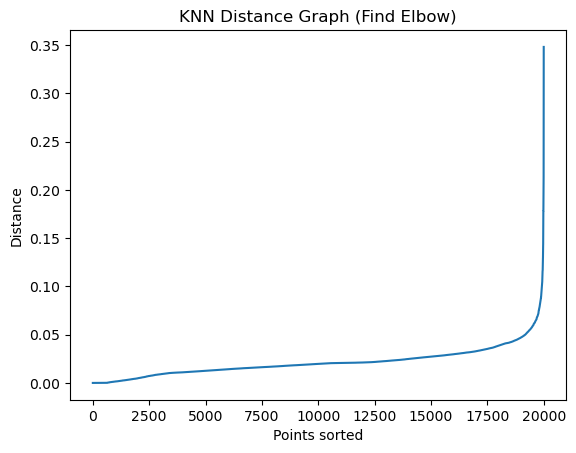

In [116]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Using 5 neighbors (standard practice)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(sample_df)

distances, indices = neighbors_fit.kneighbors(sample_df)

# Sort distances
distances = np.sort(distances[:, 4])

# Plot
plt.figure()
plt.plot(distances)
plt.title("KNN Distance Graph (Find Elbow)")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.show()

In [117]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.07, min_samples=5)

labels = dbscan.fit_predict(sample_df)

In [118]:
sample_df['cluster'] = labels

In [119]:
sample_df['cluster'].value_counts()

cluster
 1     2471
 12    1797
 13    1383
 15    1353
 6     1236
 0     1228
 10    1112
 17    1098
 5     1082
 3     1003
 11     933
 4      933
 7      850
 8      758
 2      622
 16     505
 19     344
 9      325
-1      126
 25     118
 20     118
 21     102
 22      95
 24      62
 14      55
 28      43
 26      33
 18      30
 23      24
 30      23
 35      20
 29      16
 31      12
 34       9
 37       9
 27       8
 38       8
 32       8
 44       7
 36       7
 43       7
 40       6
 41       6
 39       5
 42       5
 33       5
Name: count, dtype: int64

In [120]:
import pandas as pd
import numpy as np
import mlflow

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# ------------------------------
# Step 1: Feature Selection
# ------------------------------
X_dbscan = df_main[['latitude', 'longitude', 'region_crime_count']]

# ------------------------------
# Step 2: Scaling
# ------------------------------
scaler = StandardScaler()
X_dbscan_scaled = scaler.fit_transform(X_dbscan)

# ------------------------------
# Step 3: Sampling (for performance)
# ------------------------------
sample_size = 20000
sample_df = pd.DataFrame(X_dbscan_scaled).sample(sample_size, random_state=42)

# ✅ FIX: ensure all column names are strings
sample_df.columns = sample_df.columns.astype(str)

# ------------------------------
# Step 4: MLflow Run
# ------------------------------
with mlflow.start_run(run_name="DBSCAN_Model"):

    # Model
    dbscan = DBSCAN(eps=0.07, min_samples=5)
    labels = dbscan.fit_predict(sample_df)

    sample_df['cluster'] = labels

    # ------------------------------
    # Step 5: Noise Ratio
    # ------------------------------
    noise_ratio = (sample_df['cluster'] == -1).mean()
    print("Noise %:", noise_ratio)

    # ------------------------------
    # Step 6: Remove Noise
    # ------------------------------
    filtered_df = sample_df[sample_df['cluster'] != -1]
    filtered_labels = filtered_df['cluster']

    # ------------------------------
    # Step 7: Silhouette Score
    # ------------------------------
    if len(filtered_df['cluster'].unique()) > 1:
        score = silhouette_score(
            filtered_df.drop(columns=['cluster']),
            filtered_labels
        )
        print("Silhouette Score:", score)
    else:
        score = -1
        print("Not enough clusters for silhouette score")

    # ------------------------------
    # Step 8: MLflow Logging
    # ------------------------------
    mlflow.log_param("eps", 0.07)
    mlflow.log_param("min_samples", 5)

    mlflow.log_metric("noise_ratio", noise_ratio)
    mlflow.log_metric("silhouette_score", score)

Noise %: 0.0063
Silhouette Score: 0.40059458872317566


model 3

In [121]:
X_hier = df_main[['latitude', 'longitude', 'region_crime_count']]

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_hier_scaled = scaler.fit_transform(X_hier)

In [123]:
sample_hier = pd.DataFrame(X_hier_scaled).sample(20000, random_state=42)

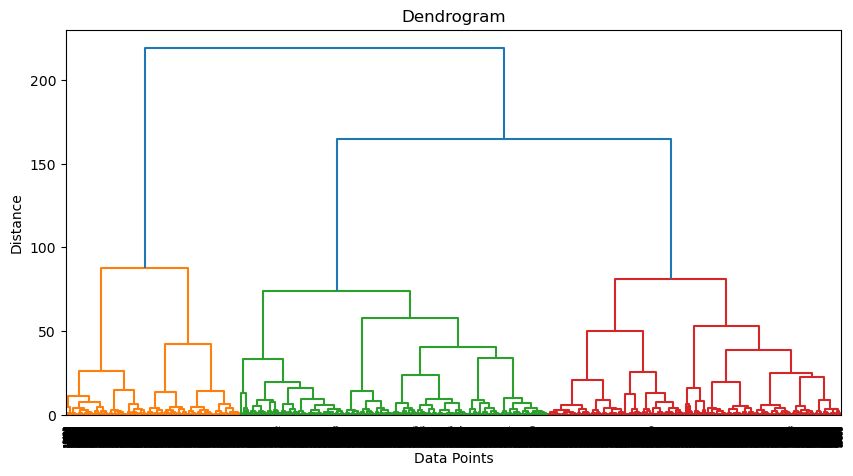

In [124]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

dendrogram = sch.dendrogram(
    sch.linkage(sample_hier, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [125]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')

labels_hier = hc.fit_predict(sample_hier)

In [126]:
sample_hier = pd.DataFrame(X_hier_scaled).sample(20000, random_state=42)

sample_hier.columns = sample_hier.columns.astype(str)

# ------------------------------
# Step 4: MLflow Run
# ------------------------------
with mlflow.start_run(run_name="Hierarchical_Model"):

    # Model
    hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
    labels_hier = hc.fit_predict(sample_hier)

    # ------------------------------
    # Step 5: Silhouette Score
    # ------------------------------
    score = silhouette_score(sample_hier, labels_hier)
    print("Silhouette Score:", score)

    # ------------------------------
    # Step 6: MLflow Logging
    # ------------------------------
    mlflow.log_param("n_clusters", 3)
    mlflow.log_param("linkage", "ward")

    mlflow.log_metric("silhouette_score", score)

Silhouette Score: 0.40218998115847326


In [127]:
import joblib

joblib.dump(geo_scaler, "geo_scaler.pkl")

['geo_scaler.pkl']

In [187]:
df_temporal=df_main.copy()

In [188]:
df_temporal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490993 entries, 2928898 to 1827039
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   490993 non-null  datetime64[ns]
 1   iucr                   490993 non-null  object        
 2   primary type           490993 non-null  object        
 3   description            490993 non-null  object        
 4   location description   490993 non-null  object        
 5   arrest                 490993 non-null  bool          
 6   domestic               490993 non-null  bool          
 7   beat                   490993 non-null  category      
 8   district               490993 non-null  category      
 9   fbi code               490993 non-null  category      
 10  year                   490993 non-null  int64         
 11  latitude               490993 non-null  float64       
 12  longitude              490993 non-null  fl

In [189]:
df_temporal.head(3)

,date,iucr,primary type,description,location description,arrest,domestic,beat,district,fbi code,year,latitude,longitude,hour,day,month,crime_severity,district_crime_count,district_avg_severity,lat_bin,lon_bin,geo_region,weekend_flag,location_category,region_crime_count,geo_cluster,geo_cluster_tuned
2928898,2014-07-18 14:48:00,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,RESIDENTIAL YARD (FRONT/BACK),True,False,613,6.0,18,2014,41.740710,-87.647400,14,Friday,7,2,28611,3.736675,0,3,0_3,0,residential,26113,5,6
4472158,2009-12-01 08:27:39,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE-GARAGE,False,False,824,8.0,14,2009,41.787487,-87.698504,8,Tuesday,12,3,32727,3.621444,1,1,1_1,0,residential,16079,5,3
337419,2024-10-09 15:20:00,0560,ASSAULT,SIMPLE,DRUG STORE,False,False,1522,15.0,08A,2024,41.880362,-87.755847,15,Wednesday,10,7,20489,3.590024,2,0,2_0,0,commercial,20693,1,5


In [190]:
day_map = {
    'Monday': 1, 'Tuesday': 2, 'Wednesday': 3,
    'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7
}

df_temporal['day_num'] = df_temporal['day'].map(day_map)

In [191]:
def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

df_temporal['season'] = df_temporal['month'].apply(get_season)

In [192]:
X_temporal = df_temporal[['hour', 'day_num', 'month', 'season', 'weekend_flag']]

In [193]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_temporal)

In [194]:
temporal_scaler = scaler

In [195]:
# sample from already scaled data
import numpy as np

sample_size = 20000
idx = np.random.choice(len(X_scaled), sample_size, replace=False)

X_sample = X_scaled[idx]

In [196]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    
    score = silhouette_score(X_sample, labels)
    scores.append((k, score))
    
    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.35834086408489746
K = 3, Silhouette Score = 0.32440667061948253
K = 4, Silhouette Score = 0.3214162019719826
K = 5, Silhouette Score = 0.3085191225229616
K = 6, Silhouette Score = 0.33533747731305813
K = 7, Silhouette Score = 0.33952906773949715
K = 8, Silhouette Score = 0.3151242734187874
K = 9, Silhouette Score = 0.30511258730562985


In [197]:
import mlflow
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

with mlflow.start_run(run_name="Temporal_KMeans"):

    for k in range(2, 10):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_sample)

        score = silhouette_score(X_sample, labels)
        scores.append((k, score))

        print(f"K = {k}, Silhouette Score = {score}")

        # ✅ Log each K score
        mlflow.log_metric(f"silhouette_k_{k}", score)

    # ✅ Final model (your existing one)
    kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
    df_temporal['temporal_cluster'] = kmeans_final.fit_predict(X_scaled)

    # ✅ Log final chosen K
    mlflow.log_param("final_k", 4)

    # ✅ Log final silhouette score on sample
    final_score = silhouette_score(X_sample, kmeans_final.fit_predict(X_sample))
    mlflow.log_metric("final_silhouette_score", final_score)

K = 2, Silhouette Score = 0.35834086408489746
K = 3, Silhouette Score = 0.32440667061948253
K = 4, Silhouette Score = 0.3214162019719826
K = 5, Silhouette Score = 0.3085191225229616
K = 6, Silhouette Score = 0.33533747731305813
K = 7, Silhouette Score = 0.33952906773949715
K = 8, Silhouette Score = 0.3151242734187874
K = 9, Silhouette Score = 0.30511258730562985


In [198]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_temporal['temporal_cluster'] = kmeans_final.fit_predict(X_scaled)

In [199]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Optional compression optimization
kmeans_final.cluster_centers_ = kmeans_final.cluster_centers_.astype("float32")

# Save model
joblib.dump(kmeans_final, "models/temporal_kmeans.pkl", compress=9)

print("Temporal model saved ✅")

Temporal model saved ✅


In [140]:
df_temporal.groupby('temporal_cluster')[['hour','day_num','month','season','weekend_flag']].mean()

,hour,day_num,month,season,weekend_flag
temporal_cluster,,,,,
0,12.467929,6.490602,8.863369,3.170575,1.0
1,13.308356,3.019925,8.882790,3.170498,0.0
2,13.337010,3.028426,3.079038,1.630171,0.0
3,12.627794,6.486362,3.090650,1.635032,1.0


<Axes: xlabel='hour'>

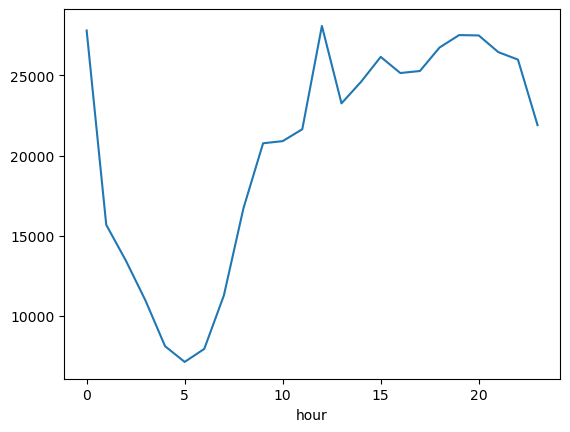

In [141]:
df_temporal['hour'].value_counts().sort_index().plot()

<Axes: xlabel='month'>

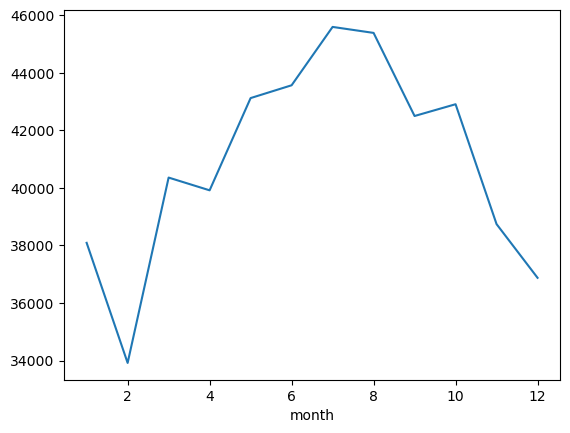

In [142]:
df_temporal['month'].value_counts().sort_index().plot()

In [143]:
df_temporal.groupby(['temporal_cluster', 'primary type']).size().unstack(fill_value=0)

primary type,ASSAULT,BATTERY,BURGLARY,CRIMINAL DAMAGE,NARCOTICS,OTHER,OTHER OFFENSE,THEFT
temporal_cluster,,,,,,,,
0,5545,17642,3956,10470,6502,17326,4794,17611
1,14309,36281,12480,23695,18483,46318,12728,47445
2,9970,24874,7490,15221,14368,30959,9755,29169
3,3441,11217,2247,6725,4838,11001,3602,10531


In [144]:
for cluster in sorted(df_temporal['temporal_cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(df_temporal[df_temporal['temporal_cluster'] == cluster]['primary type'].value_counts().head(5))


Cluster 0:
primary type
BATTERY            17642
THEFT              17611
OTHER              17326
CRIMINAL DAMAGE    10470
NARCOTICS           6502
Name: count, dtype: int64

Cluster 1:
primary type
THEFT              47445
OTHER              46318
BATTERY            36281
CRIMINAL DAMAGE    23695
NARCOTICS          18483
Name: count, dtype: int64

Cluster 2:
primary type
OTHER              30959
THEFT              29169
BATTERY            24874
CRIMINAL DAMAGE    15221
NARCOTICS          14368
Name: count, dtype: int64

Cluster 3:
primary type
BATTERY            11217
OTHER              11001
THEFT              10531
CRIMINAL DAMAGE     6725
NARCOTICS           4838
Name: count, dtype: int64


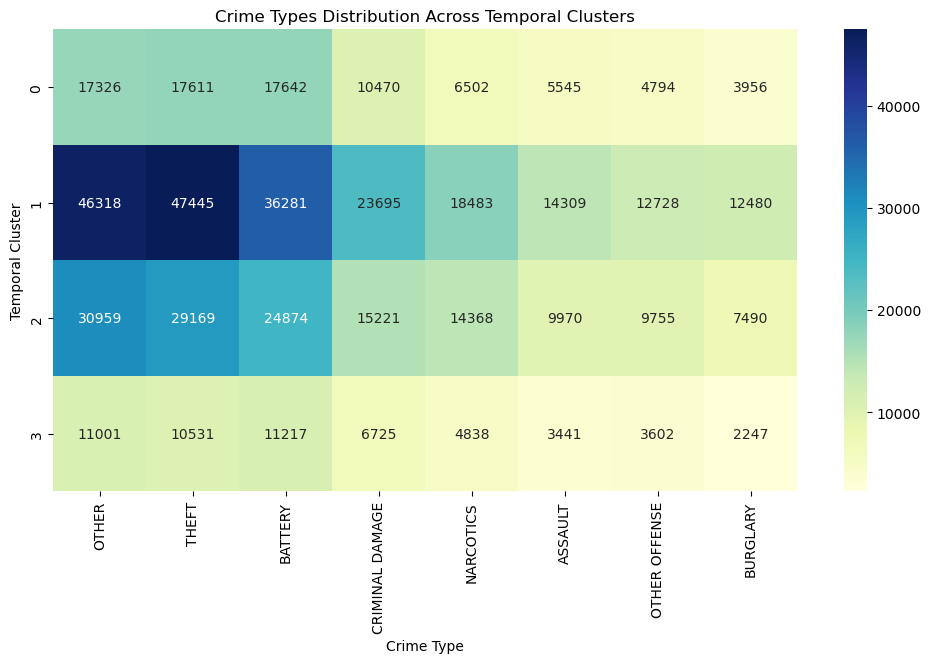

In [145]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot table
cluster_crime = df_temporal.groupby(['temporal_cluster', 'primary type']).size().unstack(fill_value=0)

# Take only top crimes overall (to avoid clutter)
top_crimes = df_temporal['primary type'].value_counts().head(10).index
cluster_crime = cluster_crime[top_crimes]

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(cluster_crime, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Crime Types Distribution Across Temporal Clusters")
plt.xlabel("Crime Type")
plt.ylabel("Temporal Cluster")
plt.show()

In [146]:
joblib.dump(temporal_scaler, "temporal_scaler.pkl")

['temporal_scaler.pkl']

In [159]:
df_pca = df_main.copy()

In [160]:
df_pca.head(2)

,date,iucr,primary type,description,location description,arrest,domestic,beat,district,fbi code,year,latitude,longitude,hour,day,month,crime_severity,district_crime_count,district_avg_severity,lat_bin,lon_bin,geo_region,weekend_flag,location_category,region_crime_count,geo_cluster,geo_cluster_tuned
2928898,2014-07-18 14:48:00,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,RESIDENTIAL YARD (FRONT/BACK),True,False,613,6.0,18,2014,41.740710,-87.647400,14,Friday,7,2,28611,3.736675,0,3,0_3,0,residential,26113,5,6
4472158,2009-12-01 08:27:39,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE-GARAGE,False,False,824,8.0,14,2009,41.787487,-87.698504,8,Tuesday,12,3,32727,3.621444,1,1,1_1,0,residential,16079,5,3


In [161]:
# Convert day (text → numeric)
df_pca['day_encoded'] = df_pca['day'].astype('category').cat.codes

# Convert primary_type
df_pca['primary type_encoded'] = df_pca['primary type'].astype('category').cat.codes

# Convert location_category
df_pca['location_category_encoded'] = df_pca['location_category'].astype('category').cat.codes

In [162]:
pca_features = [
    'latitude',
    'longitude',
    'hour',
    'month',
    'day_encoded',
    'weekend_flag',
    'crime_severity',
    'district_crime_count',
    'district_avg_severity',
    'region_crime_count',
    'primary type_encoded',
    'location_category_encoded'
]

In [163]:
X_pca = df_pca[pca_features]

In [164]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

In [165]:
pca_scaler=scaler

In [166]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca_transformed = pca.fit_transform(X_scaled)

In [167]:
pca_model=pca

In [168]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print(explained_variance)

[0.19836953 0.3424449  0.43931022 0.5323519  0.62034766 0.70363789
 0.78626991 0.85628072 0.91767282 0.96735067 0.98372552 1.        ]


In [169]:
# Get PCA loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=pca_features
)

# Check first few components
print(loadings.head())

   latitude  longitude      hour     month  day_encoded  weekend_flag  \
0  0.553557  -0.397125  0.000839  0.003768    -0.005999     -0.000466   
1  0.216369  -0.227097 -0.031431 -0.000835    -0.017901      0.063195   
2 -0.027364  -0.018169 -0.235644  0.043582    -0.659330      0.694602   
3 -0.187465  -0.249883  0.060068  0.016650     0.080194     -0.059859   
4  0.106122  -0.278971  0.254647  0.114631     0.033239     -0.013268   

   crime_severity  district_crime_count  district_avg_severity  \
0       -0.228307             -0.287089              -0.512136   
1        0.658253             -0.106348              -0.129208   
2       -0.055667              0.069896               0.005587   
3       -0.032685              0.661647              -0.086808   
4       -0.146166             -0.054806               0.158180   

   region_crime_count  primary type_encoded  location_category_encoded  
0           -0.249719              0.261192                  -0.091691  
1           -0.077

In [170]:
# Importance = absolute contribution
feature_importance = loadings.abs().mean().sort_values(ascending=False)

print(feature_importance.head(5))

longitude                0.232906
district_crime_count     0.204565
region_crime_count       0.201487
latitude                 0.199860
district_avg_severity    0.195671
dtype: float64


In [171]:
n_components = 6

In [172]:
pca_final = PCA(n_components=6)
X_pca_final = pca_final.fit_transform(X_scaled)

In [174]:
pca_model=pca_final

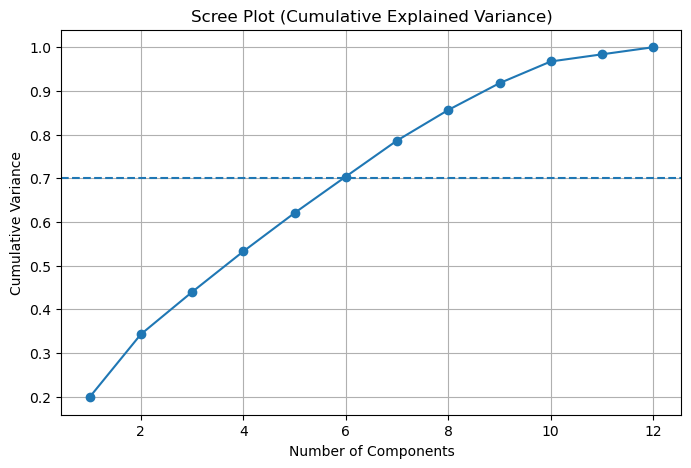

In [175]:
import matplotlib.pyplot as plt
import numpy as np

# Individual variance
explained_var = pca.explained_variance_ratio_

# Cumulative variance
cumulative_var = np.cumsum(explained_var)

# Plot
plt.figure(figsize=(8,5))

# Line plot (cumulative)
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.title("Scree Plot (Cumulative Explained Variance)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

# Horizontal line at 70%
plt.axhline(y=0.7, linestyle='--')

plt.grid()
plt.show()

PCA was applied to reduce high-dimensional crime data into a smaller set of principal components. 

The first 5–6 components captured approximately 70–80% of the total variance, indicating that most of the important information in the dataset is preserved.

This dimensionality reduction simplifies the dataset while retaining key patterns, making it easier to visualize and analyze crime trends.

Feature importance derived from PCA loadings indicates that spatial and regional factors play a dominant role in crime patterns.

Top contributing features include:
- Longitude and Latitude (geographical influence)
- District crime count (crime density)
- Region crime count (regional trends)
- District average severity (intensity of crime)

This suggests that crime is strongly influenced by location-based factors rather than isolated attributes.

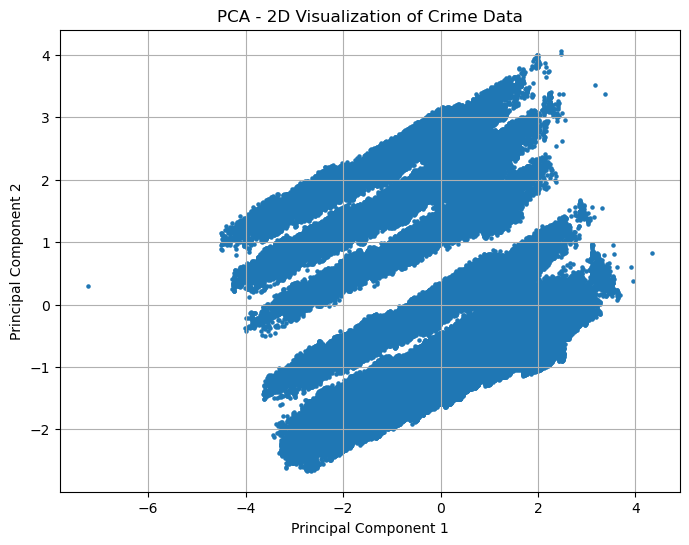

In [176]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_final[:, 0], 
    X_pca_final[:, 1], 
    s=5
)

plt.title("PCA - 2D Visualization of Crime Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid()
plt.show()

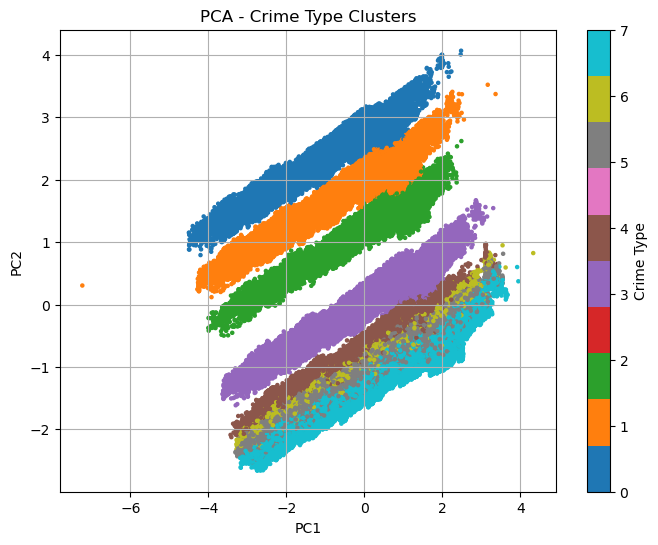

In [177]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_final[:, 0],
    X_pca_final[:, 1],
    c=df_pca['primary type_encoded'],
    cmap='tab10',
    s=5
)

plt.title("PCA - Crime Type Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Crime Type")
plt.grid()
plt.show()

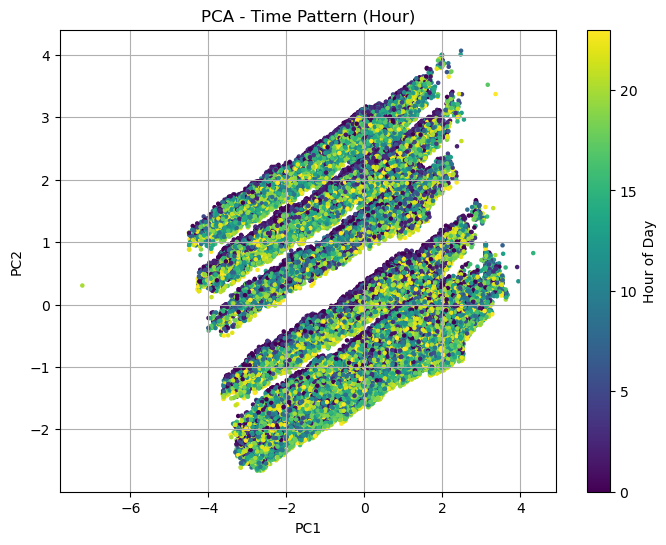

In [178]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_final[:, 0],
    X_pca_final[:, 1],
    c=df_pca['hour'],
    cmap='viridis',
    s=5
)

plt.title("PCA - Time Pattern (Hour)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Hour of Day")
plt.grid()
plt.show()

The 2D PCA visualization shows structured but overlapping clusters, indicating that while some patterns exist, crime categories are not perfectly separable in linear space.

This suggests that relationships between features are complex and may require non-linear techniques for better separation.

In [180]:
joblib.dump(pca_model, "pca_model.pkl")

['pca_model.pkl']

In [181]:
joblib.dump(pca_scaler, "pca_scaler.pkl")

['pca_scaler.pkl']

In [179]:
df_sample = df_pca.sample(n=10000, random_state=42)

In [135]:
X_sample = df_sample[pca_features]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

In [137]:
from sklearn.manifold import TSNE

In [147]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,   # try 20–50
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample_scaled)

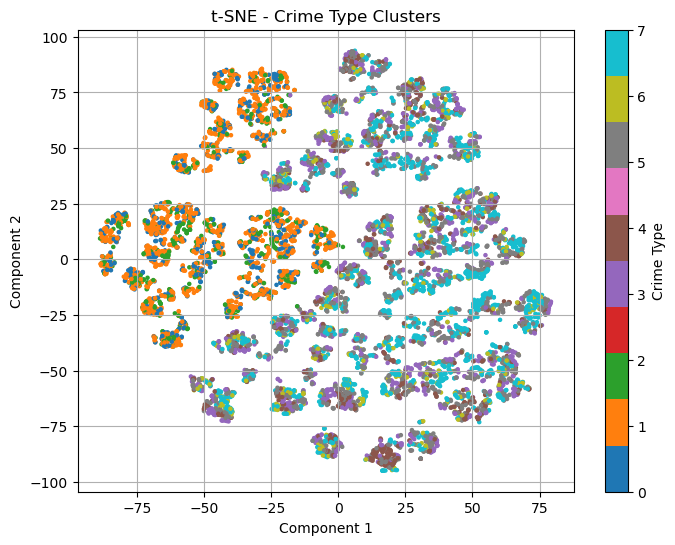

In [148]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df_sample['primary type_encoded'],
    cmap='tab10',
    s=5
)

plt.title("t-SNE - Crime Type Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.colorbar(label="Crime Type")
plt.grid()
plt.show()

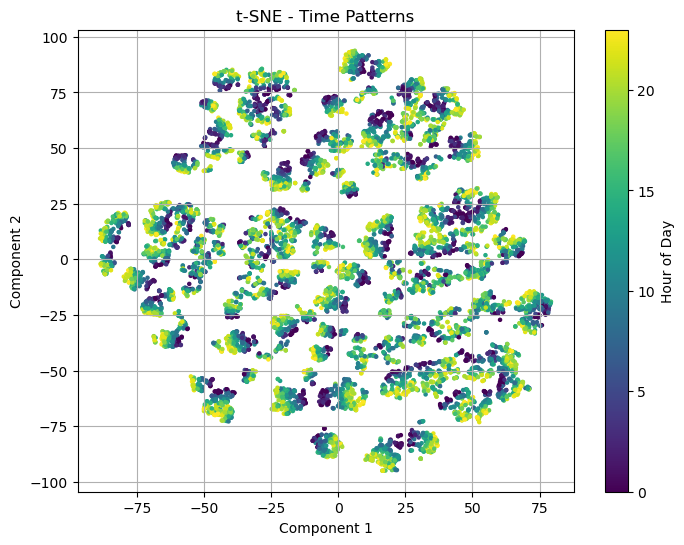

In [149]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df_sample['hour'],
    cmap='viridis',
    s=5
)

plt.title("t-SNE - Time Patterns")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.colorbar(label="Hour of Day")
plt.grid()
plt.show()

t-SNE was used to capture non-linear relationships in the data and visualize local clusters.

The results show multiple small clusters (islands), indicating the presence of localized crime patterns.

Some clusters are dominated by specific crime types, while others show overlap. This indicates that certain crimes follow distinct patterns, whereas others are influenced by multiple factors

Color-coding by hour of day shows that time-based patterns are distributed across clusters rather than forming distinct groups.

This suggests that time alone is not a strong differentiator of crime types, and crimes occur across various time periods depending on other contextual factors

Overall, the analysis indicates that crime patterns are driven by a combination of spatial, temporal, and categorical factors.

Location-based features (such as district and region) play a dominant role, while time contributes less independently.

The presence of overlapping clusters suggests that crime behavior is complex and influenced by multiple interacting variables rather than a single defining factor.

This study demonstrates that dimensionality reduction techniques like PCA and t-SNE are effective in uncovering hidden structures in crime data.

While PCA provides a global view of variance and feature importance, t-SNE reveals localized clusters and complex relationships.

These insights can help law enforcement agencies identify high-risk areas and better understand crime behavior for improved decision-making.

“PCA helped reduce dimensionality and showed that location-based features are the most important drivers of crime. t-SNE revealed localized clusters, showing that crime patterns are complex and influenced by multiple interacting factors rather than a single variable"

In [154]:
explained_var = pca_final.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

In [155]:
with mlflow.start_run():

    # PARAMETERS
    mlflow.log_param("n_components", 6)

    # METRIC
    mlflow.log_metric("explained_variance", cumulative_var[-1])

    print("PCA run logged successfully")

PCA run logged successfully


In [150]:
df_main.to_csv("geo_clusters.csv", index=False)
df_temporal.to_csv("temporal_clusters.csv", index=False)

In [200]:
df_main.to_csv("cleaned_crime_data.csv", index=False)